# 유방암 데이터셋을 활용한 이진분류 다층 퍼셉트론 모델

### 1. 데이터 불러와서 기본 정보 확인

In [235]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # 평균 0, 표준편차 1 표준화 도구
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [215]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [216]:
cancer.data # 입력 특성 데이터

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [217]:
cancer.feature_names    #각 열의 특성 이름

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [218]:
cancer.target   # 종양이 악성(0) 또는 양성(1) 표시

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [219]:
df = pd.DataFrame(
    columns= cancer.feature_names,
    data = cancer.data
)
df['class'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [220]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [221]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 2. Pytorch 텐서로 변환 

In [222]:
import torch                        # Tensor 연산 + 자동 미분 + GPU 지원
import torch.nn as nn               # 신경망 레이어
import torch.nn.functional as F     # 활성화, 손실 함수
import torch.optim as optim         # 가중치 업데이트 알고리즘

torch.from_numpy() : numpy 배열을 Pytorch 텐서로 변환  
df.values : DataFrame을 Numpy 배열 형태로 변환   
float() : 텐서를 float32 데이터 타입으로 변환  

In [223]:
data = torch.from_numpy(df.values).float()

data.shape

torch.Size([569, 31])

In [224]:
x = data[:,:-1]
y = data[:,-1:]

print(x.size(),y.size())

torch.Size([569, 30]) torch.Size([569, 1])


In [225]:
ratio = [.6,.2,.2] # 학습/검증/테스트 비율

In [226]:
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt

cnts = [train_cnt, valid_cnt, test_cnt]

print(f"학습/검증/테스트 데이터셋 수 : {train_cnt},{valid_cnt},{test_cnt}")

학습/검증/테스트 데이터셋 수 : 341,113,115


In [227]:
indices = torch.randperm(data.size(0)) # 0 ~ n-1개(568) 까지 숫자를 무작위로 섞은 텐서

x = torch.index_select(x, dim=0, index= indices)    # 섞인 인덱스 순서대로 x 재정렬
y = torch.index_select(y, dim=0, index= indices)    # 섞인 인덱스 순서대로 y 재정렬

x = x.split(cnts, dim=0)    # x를 train/valid/test 개수 기준으로 분할
y = y.split(cnts, dim=0)    # y도 동일하게 처리

for x_i,y_i in zip(x,y):
    print(x_i.size(), y_i.size())

torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])


### 3. 전처리

In [228]:
scaler = StandardScaler()       # 평균 0, 표준편차 1 의 정규화 도구
scaler.fit(x[0].numpy())        # 학습 데이터 기준으로 스케일 기준 학습

x = [
    torch.from_numpy(scaler.transform(x[0].numpy())).float(),   # train 데이터 정규화(FloatTensor형태로 최종 변환)
    torch.from_numpy(scaler.transform(x[1].numpy())).float(),   # valid 데이터 정규화(FloatTensor형태로 최종 변환)
    torch.from_numpy(scaler.transform(x[2].numpy())).float()    # test 데이터 정규화(FloatTensor형태로 최종 변환)
]

df = pd.DataFrame(x[0].numpy(), columns=cancer.feature_names)   # 스케일링된 train 데이터 DataFrame으로 변환

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.663103,-0.279595,-0.712484,-0.660871,-0.983603,-1.095576,-0.890842,-0.931172,0.191462,-0.256020,-0.690547,-1.076892,-0.725258,-0.544030,0.074638,-0.951363,-0.622311,-0.604246,-0.073620,-0.436310,-0.687206,-0.743747,-0.736328,-0.644480,-0.777601,-1.075717,-0.902808,-0.812941,-0.198845,-0.586598
1,-0.937101,-0.512283,-0.875670,-0.849172,-0.519734,0.085135,0.036140,-0.356150,-1.154730,0.463024,-0.578809,0.262066,-0.071611,-0.528503,0.502262,1.084766,1.042920,0.904576,-0.652461,0.371290,-0.835001,0.146631,-0.550452,-0.729460,0.296732,0.916116,0.976627,0.588043,-0.586670,0.625476
2,0.771856,1.004665,0.808265,0.654389,1.647117,0.794042,1.858275,1.781642,1.541207,0.112999,0.696341,0.301707,0.534765,0.604759,0.408532,0.251025,0.591398,-0.117931,0.054207,-0.015778,0.866637,0.985578,0.769933,0.721893,1.353667,0.589698,1.370662,1.030109,0.980460,0.026287
3,1.497809,-0.299731,1.542192,1.550885,1.100971,1.108701,1.970975,1.992449,0.756224,-0.294008,1.199348,-0.328942,0.937830,1.273572,-0.920418,-0.180313,0.261865,0.179780,-0.447455,-0.200688,2.035015,0.069486,1.884617,2.207373,0.501160,0.768822,1.965855,1.635678,1.159335,0.449143
4,1.331150,-0.129690,1.242881,1.334381,-1.014811,-0.489025,0.013104,0.155376,0.468515,-1.702250,1.025616,0.200803,1.153340,0.911879,-0.803334,0.062951,0.265443,0.270185,-0.032619,-0.418716,1.154238,-0.036588,1.117553,1.046424,-1.312593,-0.218544,0.210962,0.077851,-0.110199,-1.081356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,-0.067087,1.713917,-0.069989,-0.197097,0.199476,0.109197,-0.582468,-0.180646,-0.984237,-0.173262,-0.181230,0.471081,-0.029933,-0.261571,0.089155,0.034552,-0.375080,0.683241,0.027677,0.484443,-0.247816,1.159153,-0.261438,-0.344206,-0.355697,-0.218544,-0.705206,-0.179516,-1.045729,-0.065589
337,-0.431476,-0.145352,-0.459914,-0.492796,0.020028,-0.503092,-0.802169,-0.821450,-0.195701,-0.156982,-0.712821,0.098098,-0.717634,-0.548825,-0.430938,-0.518417,-0.551395,-0.292973,-0.178535,-0.609490,-0.557386,0.005199,-0.617103,-0.556656,-0.107774,-0.483797,-0.739788,-0.507734,-0.263746,-0.683609
338,-0.584011,0.123135,-0.558318,-0.616716,0.930744,0.157321,-0.122630,-0.723666,1.100764,0.807623,-0.862052,-0.783190,-0.996831,-0.655690,-0.221386,-0.222643,0.241371,-0.309028,-0.888822,-0.029923,-0.675222,-0.287308,-0.694384,-0.664387,0.344577,-0.186714,0.370719,-0.541646,-0.319150,0.230011
339,1.110822,-0.176675,1.115776,1.035264,1.299569,0.773682,1.059473,1.418443,0.987101,0.015318,1.560548,0.653069,0.981034,1.313304,-0.970282,0.186191,-0.132403,-0.413773,0.743993,0.423037,0.810715,-0.293737,0.741204,0.683418,-0.186065,-0.197948,-0.073484,0.239841,0.174734,-0.256188


### 4. 모델&옵티마이저 구성
- 입력 특성 x[0].size(-1) => 30
- 은닉층 25 -> 20 -> 15 -> 5 노드로 점차 축소하는 방식
- 각 은닝층 사이사이에 LeakReLU 함수 적용
- 출력층 1개 노드
- 출력층 활성화 함수 Sigmoid => 0 ~ 1 이진 분류 확률값 출력

In [229]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25),   # 입력 특성수 -> 은닉층 25개 노드
    nn.LeakyReLU(),                 # 음수 영역도 기울기 어느정도 유지하는 활성화 함수

    nn.Linear(25, 20),  # 은닉층 25개 -> 20개
    nn.LeakyReLU(),

    nn.Linear(20, 15),  # 은닉층 20개 -> 15개
    nn.LeakyReLU(),

    nn.Linear(15, 10),
    nn.LeakyReLU(),

    nn.Linear(10, 5),
    nn.LeakyReLU(),
    
    nn.Linear(5,y[0].size(-1)), # 은닉층 5개 노드 -> 이진 분류는 1개
    nn.Sigmoid()                # 출력값을 0 ~ 1 확률로 변환
)

model

Sequential(
  (0): Linear(in_features=30, out_features=25, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=25, out_features=20, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=20, out_features=15, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=15, out_features=10, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=10, out_features=5, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=5, out_features=1, bias=True)
  (11): Sigmoid()
)

In [230]:
# Adam 계열 최적화함수 : 학습률을 자동 조절해주는 대표 옵티마이저
optimizer = optim.Adam(model.parameters())

### 5. 학습

In [231]:
n_epochs = 10000            # 학습 반복 횟수
batch_size = 32             # 한번에 학습할 샘플 수 (미니배치 크기)
print_interval = 100        # loss 출력
early_stop = 1000           # 성능 개선 없을 경우 학습을 중단할 최대 대기 에폭 수

In [232]:
# 모델 저장 설정 
from copy import deepcopy   # 객체 완전 복사 (best_model 저장용)

lowest_loss = np.inf        # 최소 손실값(매우 큰 값)
best_model = None           # 최고 성능 모델 저장

lowest_epoch = np.inf       # 최고 손실이 나온 epoch 기록

In [233]:
train_history, valid_history = [],[]

for i in range(n_epochs):
    indices = torch.randperm(x[0].size(0)) # 0 ~ n-1개 까지 숫자를 무작위로 섞은 텐서

    x_ = torch.index_select(x[0], dim=0, index= indices)    # 섞인 인덱스 순서대로 x 재정렬
    y_ = torch.index_select(y[0], dim=0, index= indices)    # 섞인 인덱스 순서대로 y 재정렬

    x_ = x_.split(batch_size, dim=0)    # 배치 크기 단위로 분할
    y_ = y_.split(batch_size, dim=0)    # y도 동일하게 처리

    train_loss, valid_loss = 0, 0   # epochs별 손실 초기화
    y_hat = []  # 검증 예측값 저장

    # 미니 배치 단위로 학습
    
    for x_i,y_i in zip(x_,y_):
        y_hat_i = model(x_i)    # 순전파 진행 (예측)
        loss = F.binary_cross_entropy(y_hat_i,y_i)  # 이진 분류 손실 계산

        optimizer.zero_grad()   # 이전 기울기값 초기화
        loss.backward()         # 역전파 : 기울기 재계산

        optimizer.step()        # 가중치 업데이트
        train_loss += float(loss)   # Tensor -> float 형태로 배치단위별 train_loss 총합

    train_loss = train_loss / len(x_)   # 평균 학습 손실

    # 검증 단계 (기울기 계산 하지않음)
    with torch.no_grad():
        x_ = x[1].split(batch_size,dim=0)   # 검증 데이터도 배치 분할
        y_ = y[1].split(batch_size,dim=0)   # 검증 데이터도 배치 분할

        valid_loss = 0 

        # 배치 단위로 검증데이터 순회
        for x_i,y_i in zip(x_,y_):  
            y_hat_i = model(x_i)    # 순전파 (예측)
            loss = F.binary_cross_entropy(y_hat_i,y_i)   # 검증 손실 계산

            valid_loss += float(loss)   # epochs별 valid_loss 총합

            y_hat += [y_hat_i]      # 예측갑 저장

    valid_loss = valid_loss / len(x_)   # 평균 검증 손실

    # 시각화용 기록
    train_history += [train_loss]   # epochs별 학습 솔실
    valid_history += [valid_loss]   # epochs별 검증 솔실


    # 로그 확인용
    if (i + 1) % print_interval == 0:   # 100번마다 한번씩
        print(f"Epoch {i+1} : traind loss = {train_loss}, valid_loss = {valid_loss}, lowest_loss = {lowest_loss}")

    # 최저 손실값 갱신시
    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss    # 최소 손실값 갱신
        lowest_epoch = i            # 해당 epoch를 최소 손실 epoch로 저장

        best_model = deepcopy(model.state_dict())   # 최적 모델은 가중치 저장
        
    # 일정 epoch동안 성능 개선 없으면 종료시키는 early stopping 구문
    else: 
        # 현재 epoch - 마지막으로 성능이 좋아진 epoch이 aearly stop 기준보다 커지만
        if early_stop > 0 and (i + 1) - lowest_epoch >= early_stop:
            print(f"{early_stop} epoch 동안 향상된 기록이 없습니다.")
            break
print(f"최고 검증 성능의 에포크는 {lowest_epoch+1}, 그떄의 최저 손실 : {lowest_loss:.4e}")
model.load_state_dict(best_model)   # 최적 성능 모델 복원

Epoch 100 : traind loss = 0.0003182047492538748, valid_loss = 0.8899200204832596, lowest_loss = 0.12505482521373779
Epoch 200 : traind loss = 4.473516620154524e-05, valid_loss = 1.5627213682564616, lowest_loss = 0.12505482521373779
Epoch 300 : traind loss = 9.964718422204236e-06, valid_loss = 1.5626832462876337, lowest_loss = 0.12505482521373779
Epoch 400 : traind loss = 3.7725397748741587e-06, valid_loss = 1.5626527145286673, lowest_loss = 0.12505482521373779
Epoch 500 : traind loss = 2.0686395129390887e-06, valid_loss = 1.56263175093045, lowest_loss = 0.12505482521373779
Epoch 600 : traind loss = 8.126946092409937e-07, valid_loss = 1.5626193194912048, lowest_loss = 0.12505482521373779
Epoch 700 : traind loss = 3.8811996057445825e-07, valid_loss = 1.5626075018808478, lowest_loss = 0.12505482521373779
Epoch 800 : traind loss = 1.961790259408236e-07, valid_loss = 1.5626064907992259, lowest_loss = 0.12505482521373779
Epoch 900 : traind loss = 1.0000575745022745e-07, valid_loss = 1.562598

<All keys matched successfully>

valid_loss += float(loss) # Tensor -> float (메모리 누수 방지)  

loss는 Tensor. autograd 그래프를 가지고 있음  
train_loss 또는 valid_loss가 더해질 때마다 이전 loss 연산 그래프를 함께 참조 => 메모리 공간 또는 CPU/GPU 메모리 공간을 차지한다.  
그래서 Python float형태로 바꿔 숫자만 실수형으로 가져와서 저장하면 계산 그래프를 그리지않음

### 6. 손실기록 또는 손실 변화 이력 그래프

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

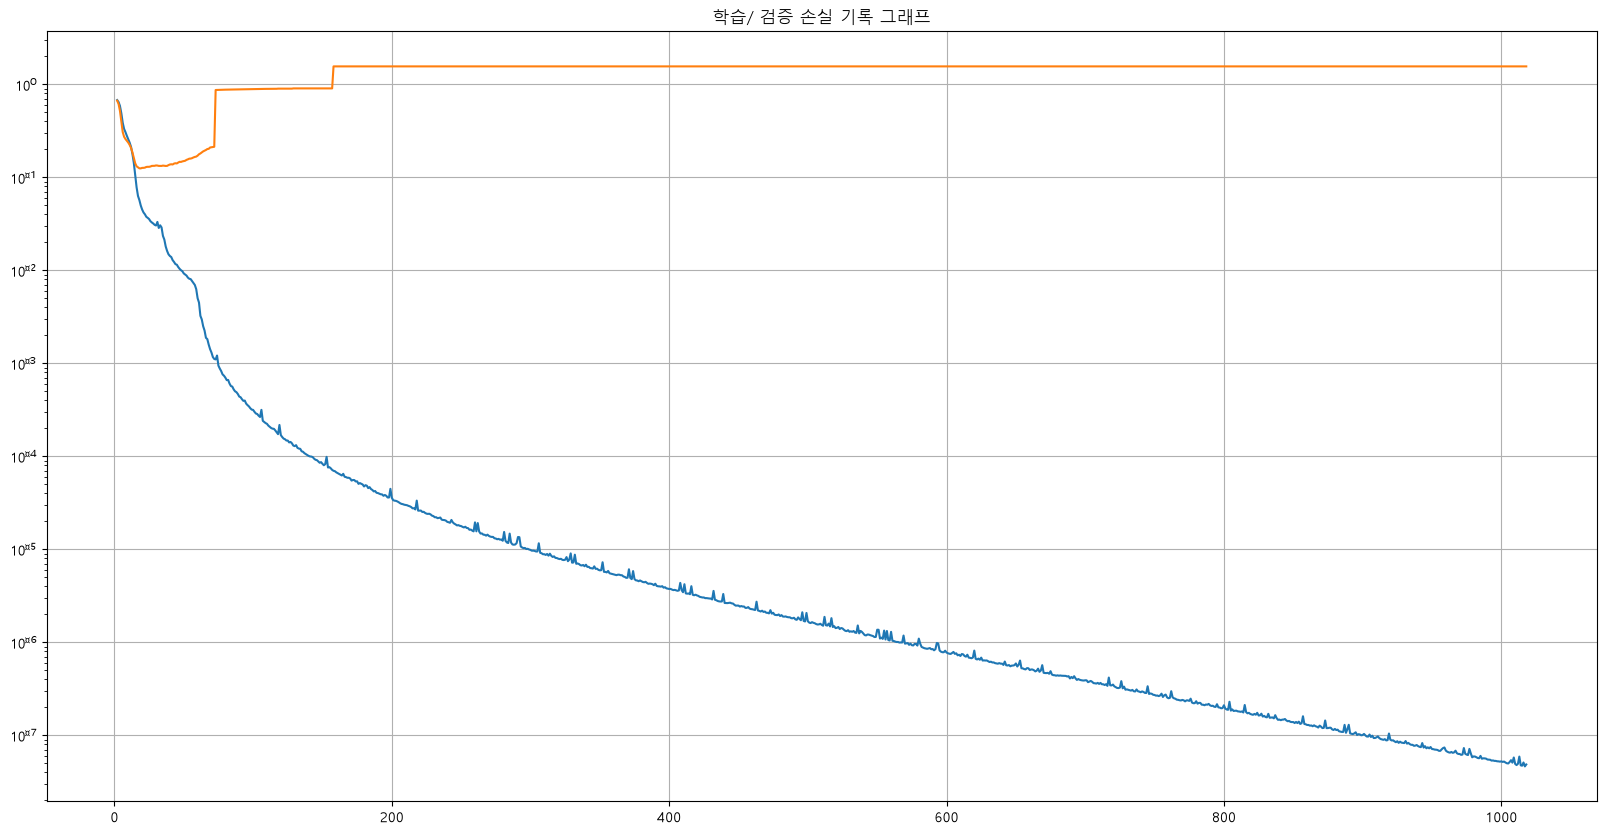

In [237]:


plot_from = 2   # 0번,1번 초반 에폭은 불안정하므로 3번째 에폭부터 사용하기 위한 설정

plt.figure(figsize= (20,10))
plt.grid(True)
plt.title("학습/ 검증 손실 기록 그래프")

# 학습 / 검증 손실 곡선
plt.plot(
    range(plot_from,len(train_history)),train_history[plot_from:],  # 학습 그래프
    range(plot_from,len(valid_history)),valid_history[plot_from:]   # 검증 그래프
)

plt.yscale('log')   # y축은 로그 스케일 적용
plt.show()

### 7. 테스트 데이터로 결과 확인

In [240]:
test_loss = 0
y_hat = []

with torch.no_grad():
    x_ = x[2].split(batch_size,dim=0)   # 테스트 데이터도 배치 분할
    y_ = y[2].split(batch_size,dim=0)   # 테스트 데이터도 배치 분할

    valid_loss = 0 

    # 배치 단위로 테스트 데이터 순회
    for x_i,y_i in zip(x_,y_):  
        y_hat_i = model(x_i)    # 순전파 (예측)
        loss = F.binary_cross_entropy(y_hat_i,y_i)   # 손실 계산

        test_loss += float(loss)   # epochs별 test_loss 총합

        y_hat += [y_hat_i]      # 예측값 저장

test_loss = test_loss / len(x_)   # 평균 테스트 손실

y_hat = torch.cat(y_hat, dim= 0)    # 배치멸 예측 결과를 하나의 Tensor로 결합

print(f"Test Loss : {round(test_loss, 4)}")

Test Loss : 0.0675


In [242]:
corrent_cnt = (y[2] == (y_hat > .5)).sum()

total_cnt = float(y[2].size(0))

print(f"테스트 정확도는 ? {corrent_cnt/total_cnt * 100:.2f}%")

테스트 정확도는 ? 98.26%


y_hat > .5 : 예측 확률이 0.5보다 크면 True, 아니면 False  
  
y[2] == : True =1 , Flase = 0 각각 맞는지 True, Flase 반환

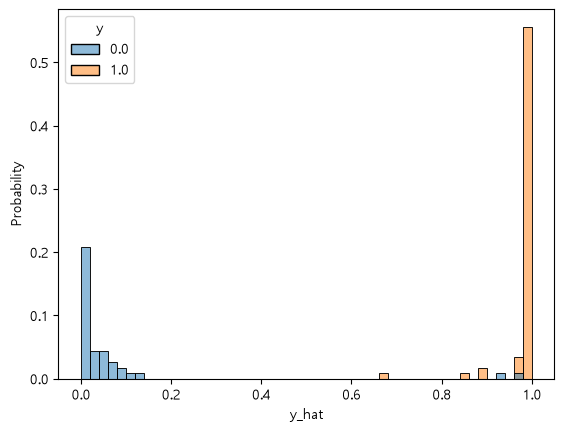

In [ ]:
# 시각화
df = pd.DataFrame(
    torch.cat([y[2],y_hat], dim = 1)    # 실제값과 예측값을 열 방향으로 합침
    .detach().numpy(),  # autograd 그래프에서 분리
    columns= ["y","y_hat"]  # numpy 배열 형태로 변환
)

sns.histplot(
    df,
    x='y_hat',  # x축 : 모델 예측값
    hue='y',    # 색상 구분 : 실제 데이터
    bins=50,        
    stat='probability'  # 빈도를 확률(비율)로 정규화
)
plt.show()

확신을 가지고 선택한 결과가 많아 모델 학습이 잘 된것으로 보임

In [248]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df.values[:,0], # 실제값 (0또는 1)
    df.values[:,1], # 예측 확률값 (0 ~1)
)

0.997093023255814

roc 기준 1.0 -> 완벽한분류  
